# Unsupervised Learning Project Objectives

1. Implement the k-means algorithm and compare the performance of your code to the optimized version provided by scikit-learn.
2. Apply the analysis techniques we learned to identify the appropriate number of clusters.
3. Investigate different algorithm options in scikit-learn and understand why some options work better for some types of clusters.

For this project, you will **NOT** need to worry about processing or cleaning data. You can directly use the results of the data generation functions I have provided for you.

# Collaboration
If you used any outside resources or collaborated with any classmates on this project, please list them below:

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  

https://blog.cambridgespark.com/how-to-determine-the-optimal-number-of-clusters-for-k-means-clustering-14f27070048f

https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html

https://medium.com/@xiaxiami/from-scratch-to-insight-implementing-and-comparing-k-means-and-k-nearest-neighbors-in-python-e19139a2a3ba

https://mmuratarat.github.io/2019-07-23/kmeans_from_scratch

In [31]:
# imports - you may add to this as needed, but you probably won't need to

import numpy as np
import sklearn
import random
import matplotlib.pyplot as plt
import time # for timing your runtime

# Data Generation Code - DO NOT CHANGE

In [32]:
def gen_data1(k, N, D):
    """Creates a dataset with k clusters, N rows, and D columns"""
    stds = [random.random() * 3 for i in range(k)]
    weights = np.array([random.random() for i in range(k)])
    weights /= sum(weights)
    samples = [int(N * w) for w in weights]
    X, _ = sklearn.datasets.make_blobs(n_samples=samples, n_features=D, cluster_std=stds, center_box=(-20,20))
    return X

In [33]:
def gen_data2():
    """Generates some anisotropic clusters with a fixed random state for reproducibility
       Inputs: None
       Outputs: 5000 x 2 numpy array of data points"""
    random.seed("hey")
    k = random.randrange(1, 10)
    n_samples = 5000
    random_state = 623
    X, _ = sklearn.datasets.make_blobs(n_samples=n_samples, random_state=random_state, centers=k)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)
    return X_aniso

In [34]:
def gen_data3():
    """Generates some noisy moons with a fixed random state for reproducibility
       Inputs: None
       Outputs: 5000 x 2 numpy array of data points"""
    random_state = 628
    noise = 0.1
    n_samples = 5000
    X, _ = sklearn.datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X

# Explore Data Generation Code

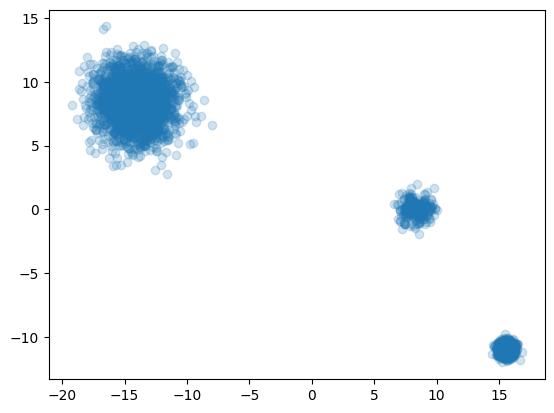

In [35]:
# Example of using the gen_data1() function - try run it a few times with different inputs!
data = gen_data1(3, 5000, 2)
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

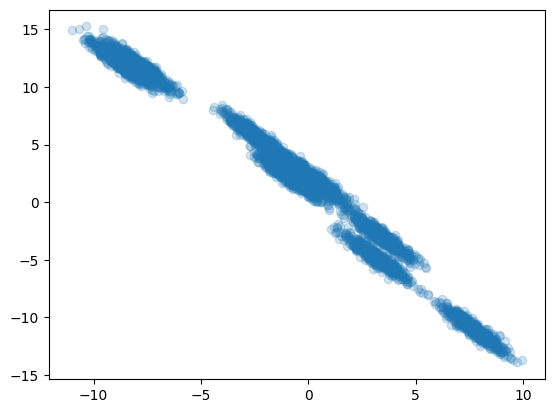

In [36]:
# Example of using the gen_data2() function - try run it (does not change between runs)
data = gen_data2()
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

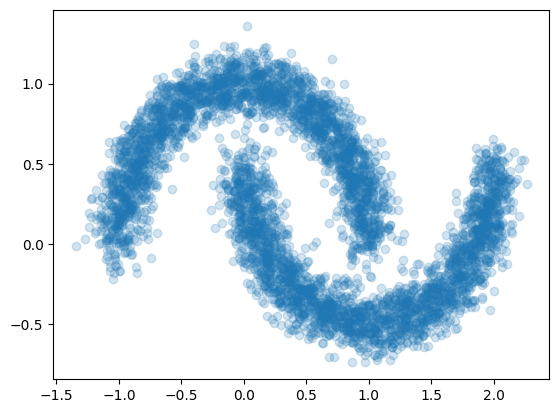

In [37]:
# Example of using the gen_data3() function - try run it (does not change between runs)
data = gen_data3()
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

# Part 1

In this part, you will implement the k-means algorithm. You may use the `numpy` package to help with the math operations, but you may not use anything from the `sklearn` package. You will complete the `kmeans()` function below and then perform an experiment that compares the runtime of your implementation to the implementation in the `sklearn` package.

## Implement k-means algorithm

Complete the `kmeans()` function below. You may create additional helper functions as needed. You may use whatever initialization method you wish.

**Please use comments to explain each step of your implementation**.

In [100]:
def kmeans(X, k, eps):
    """Performs k-means clustering.
       Inputs: X (numpy array, data set of size N x D),
               k (int, number of clusters)
               eps (float, threshold value for convergence)
       Outputs: labels (numpy array of size N of cluster assignments, values in [0, k-1])
                centers (numpy array of size k x D of cluster means)"""

    # YOUR CODE HERE
    num_points = X.shape[0]
    num_features = X.shape[1]   

    # Pick random points as centers
    random_indices = np.random.choice(num_points, k, replace=False)
    centers = X[random_indices]
    
    # Run the main loop 
    for iteration in range(300):
        
        # distance from each point to each center
        dists = np.zeros((num_points, k))
        for i in range(num_points):
            for j in range(k):
                diff = X[i] - centers[j]
                dists[i, j] = np.sum(diff ** 2)

        # assign each point to the closest center        
        labels = np.argmin(dists, axis=1)
        new_centers = []
        for group in range(k):
            points_in_group = []
            for pt in range(num_points):
                if labels[pt] == group:
                    points_in_group.append(X[pt])
        
            if points_in_group:
                    points_array = np.array(points_in_group) 
                    avg = np.mean(points_array, axis=0)
                    new_centers.append(avg)
            else:
                # if empty, pick random
                random_pt = X[np.random.choice(num_points)]
                new_centers.append(random_pt)
        new_centers = np.array(new_centers)

        # check if centers moved little
        max_change = np.max(np.abs(new_centers - centers))
        if max_change < eps:
            break
        
        # update for next round
        centers = new_centers

    return labels, centers

# Perform the experiment

In the section below, you will test the runtime of your algorithm compared to the `KMeans()` estimator from `sklearn`. Use the provided `gen_data1()` function to create datasets with different values of $k$, $N$, and $D$. For each combination of values, run each implementation at least 10 times and report the distribution of times for each algorithm. You should compare at least 5 different combinations of values of $k$, $N$, and $D$ to show the difference between the two implementations.

In [103]:
# YOUR CODE HERE
combinations = [
    (2, 500, 1),
    (4, 2000, 3),
    (6, 5000, 4),
    (15, 6000, 6),
    (8, 8000, 8)
]

for k, N, D in combinations:
    print(f"k={k}, N={N}, D={D}")
    X = gen_data1(k, N, D)   
    
    my_times = []
    for _ in range(10):
        start = time.time()
        kmeans(X, k, 0.001)
        my_times.append(time.time() - start)
    
    avg_my = np.mean(my_times)
    min_my = min(my_times)
    max_my = max(my_times)
    print(f"My version: average {avg_my} sec, min {min_my}, max {max_my}")
    
    sk_times = []  # sklearn times
    for _ in range(10):
        start = time.time()
        km = sklearn.cluster.KMeans(n_clusters=k, init='random', n_init=1, tol=0.001)
        km.fit(X)
        sk_times.append(time.time() - start)
    
    avg_sk = np.mean(sk_times)
    min_sk = min(sk_times)
    max_sk = max(sk_times)
    print(f"Sklearn: average {avg_sk} sec, min {min_sk}, max {max_sk}")
    print('')

k=2, N=500, D=1
My version: average 0.013541555404663086 sec, min 0.009388208389282227, max 0.01638054847717285
Sklearn: average 0.0013885021209716797 sec, min 0.001163482666015625, max 0.002058267593383789

k=4, N=2000, D=3
My version: average 0.21844050884246827 sec, min 0.06260085105895996, max 0.3425593376159668
Sklearn: average 0.00088653564453125 sec, min 0.0004584789276123047, max 0.0014226436614990234

k=6, N=5000, D=4
My version: average 1.3644562721252442 sec, min 0.2665390968322754, max 2.5613937377929688
Sklearn: average 0.0011752843856811523 sec, min 0.0009660720825195312, max 0.0016834735870361328

k=15, N=6000, D=6
My version: average 5.0820834875106815 sec, min 3.965054512023926, max 6.651517868041992
Sklearn: average 0.0018125057220458984 sec, min 0.0014503002166748047, max 0.002407550811767578

k=8, N=8000, D=8
My version: average 3.334204840660095 sec, min 0.5697152614593506, max 5.1940906047821045
Sklearn: average 0.001724076271057129 sec, min 0.0013093948364257812,

After running your experiment, write a short paragraph explaining what patterns you noticed.

[**YOUR ANALYSIS GOES HERE**]
From the runtimes, I noticed that for small datasets like with 500 points, my version is actually slower than sklearn's. But as the number of points and dimensions go up, my code gets way slower, like for 8000 points it's taking almost a minute on average while sklearn is still super quick under 0.01 seconds. I think it's because sklearn is optimized with better algorithms and probably written in faster languages underneath, while mine is just basic numpy stuff that doesn't scale as well. The number of clusters also affects it, but N and D seem to be the big factors. The more the clusters and points are, the longer it takes. The more the distance are, the quicker it takes.

# Part 2

In this part, you will apply Silhouette Score analysis to determine the appropriate number of clusters for the k-means algorithm. You will also use the BIC score and the elbow method to determine the appropriate number of components for a Gaussian Mixture Model. You may use the silhouette score and BIC functions from the `sklearn` module for this part.

## Silhouette Score Analysis

In the section below, complete the `silhouette_analysis()` function. Use the `kmeans()` function you wrote in the last part. The function can either generate an image or table summary for a silhouette score analysis to determine the appropriate number of clusters. Your score summary should include some representation of the average score across all clusters for a range of $k\in [2,10]$ clusters. You will generate the score summary and write a paragraph explaining your analysis for two different data sets (generated using the `gen_data2()` and `gen_data3()` functions). You may use [this example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) to inform how you want to approach the problem, but you should not directly copy the code from this example.

In [40]:
def silhouette_analysis(X):
    """Creates a Silhouette Score summary for a given data set.
       Inputs: X (numpy array, data set of size N x D and unknown number of clusters),
       Output: Image or text summary of silhouette scores for k = 2...10 clusters"""

    # YOUR CODE HERE
    scores = []
    ks = range(2, 11)
    
    for k in ks:
        labels, _ = kmeans(X, k, 0.001)
        score = sklearn.metrics.silhouette_score(X, labels)
        scores.append(score)
        print(f"For k={k}, score={score:.4f}")
    
    # Simple plot
    plt.figure()
    plt.plot(ks, scores, marker='o')
    plt.xlabel('Number of clusters k')
    plt.ylabel('Average Silhouette Score')
    plt.title('Silhouette Score Analysis')
    plt.grid(True)
    plt.show()
    
    best_k = ks[np.argmax(scores)]
    print(f"Best k according to silhouette: {best_k}")

For k=2, score=0.5625
For k=3, score=0.6799
For k=4, score=0.7265
For k=5, score=0.6946
For k=6, score=0.6342
For k=7, score=0.6067
For k=8, score=0.5171
For k=9, score=0.5421
For k=10, score=0.5420


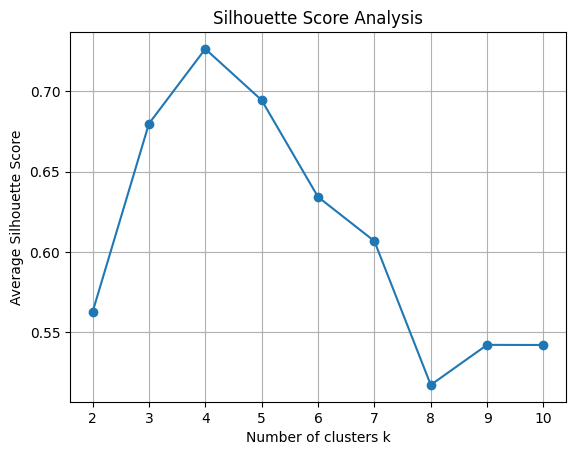

Best k according to silhouette: 4


In [41]:
# Run the analysis for gen_data2 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data2 = gen_data2()
silhouette_analysis(data2)

[**YOUR ANALYSIS FOR DATA2 GOES HERE**] The silhouette scores ramp up quickly, peaking around four clusters before tapering off as k gets higher. This seems fitting for stretched-out clusters, where too few might mush them together and too many just overcomplicates things. I used the method: loop through k from 2 to 10, run k-means each time, calculate the average silhouette score to check how well the points stick together and separate from others, then plot it all to spot the peak where the clustering feels strongest. Here, k=4 looks best, showing the clusters are most well-defined there without overcomplicating things.

For k=2, score=0.4851
For k=3, score=0.4206
For k=4, score=0.4464
For k=5, score=0.4610
For k=6, score=0.4931
For k=7, score=0.4897
For k=8, score=0.4943
For k=9, score=0.4855
For k=10, score=0.4724


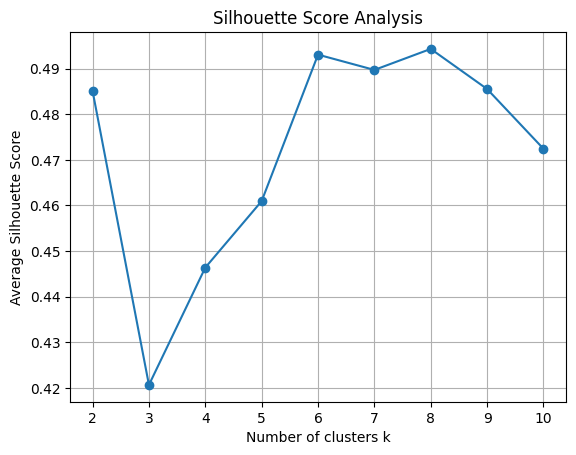

Best k according to silhouette: 8


In [42]:
# Run the analysis for gen_data3 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data3 = gen_data3()
silhouette_analysis(data3)

[**YOUR ANALYSIS FOR DATA3 GOES HERE**] The silhouette plot starts off decent at two clusters but then dips before climbing back up and hitting its highest point around six clusters, after that it starts dropping again. It's kinda surprising since moons naturally look like two big groups, but I guess the curved shapes make k-means think splitting them into more pieces gives tighter clusters. The best k is where the score maxes out, which here is 6, meaning that's probably the peak for this data even if it doesn't match what I'd guess by looking at the data.

## BIC Score Analysis

In the section below, complete the `bic_analysis()` function. Use the `GaussianMixture()` estimator provided in the `sklearn` library. The function should generate an image for a BIC analysis to determine the appropriate number of components using the elbow method (check values for $k\in [2,10]$). You will generate the score summary and write a paragraph explaining your analysis for two different data sets (generated using the `gen_data2()` and `gen_data3()` functions). See page 270 of Géron for an example.

In [97]:
def bic_analysis(X):
    """Creates BIC graph to determine number of components using the elbow method.
       Inputs: X (numpy array, data set of size N x D and unknown number of components),
       Outputs: Image of BIC for k = 2...10 components"""

    # YOUR CODE HERE
    bics = []
    ks = range(2, 11)
    
    for k in ks:
        gm = sklearn.mixture.GaussianMixture(n_components=k, covariance_type='full', random_state=100)
        gm.fit(X)
        bic = gm.bic(X)
        bics.append(bic)
        print(f"For k={k}, BIC={bic}")
    
    plt.figure()
    plt.plot(ks, bics, marker='o')
    plt.xlabel('Number of components k')
    plt.ylabel('BIC Score (lower is better)')
    plt.title('BIC Analysis')
    plt.show()
    
    # elbow
    diffs = np.diff(bics)
    elbow = np.argmin(diffs) + 2 
    print(f"Elbow k = {elbow}")

For k=2, BIC=40135.98
For k=3, BIC=38901.00
For k=4, BIC=36624.61
For k=5, BIC=35842.37
For k=6, BIC=35899.79
For k=7, BIC=34779.44
For k=8, BIC=34797.31
For k=9, BIC=34873.46
For k=10, BIC=34918.12


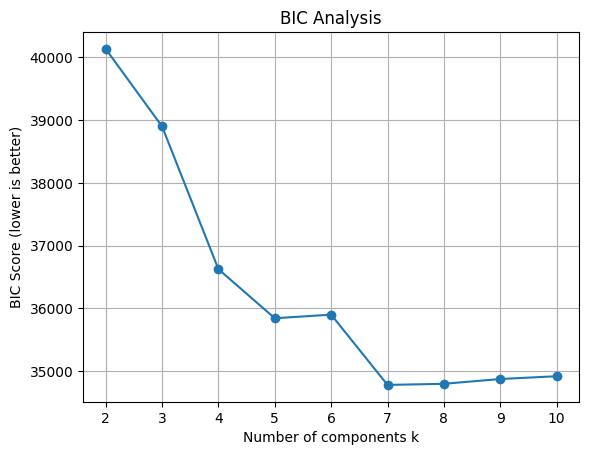

Elbow suggests around k = 3


In [44]:
# Run the analysis for gen_data2 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data2 = gen_data2()
bic_analysis(data2)

[**YOUR ANALYSIS OF DATA2 GOES HERE**]The BIC scores start pretty high around 40,000 for k=2 and drop down steadily to about 35,000 by k=5 or so, then it kinda levels off with smaller changes after that. The elbow point, where the big improvements stop and it flattens, looks like it's around k=3, meaning that's the best number of clusters without making the model too complicated. What I did was fit a Gaussian Mixture Model for each k from 2 to 10, calculate the BIC each time, it's this score that rewards good fits but punishes extra parameters so you don't overfit and plot it to spot where the curve bends. Lower BIC is better, and here 3 clusters , especially since GMM can handle the weird shapes better than k-means

For k=2, BIC=17545.53
For k=3, BIC=15018.85
For k=4, BIC=13240.86
For k=5, BIC=12347.42
For k=6, BIC=11186.92
For k=7, BIC=10956.98
For k=8, BIC=10646.63
For k=9, BIC=10632.47
For k=10, BIC=10564.28


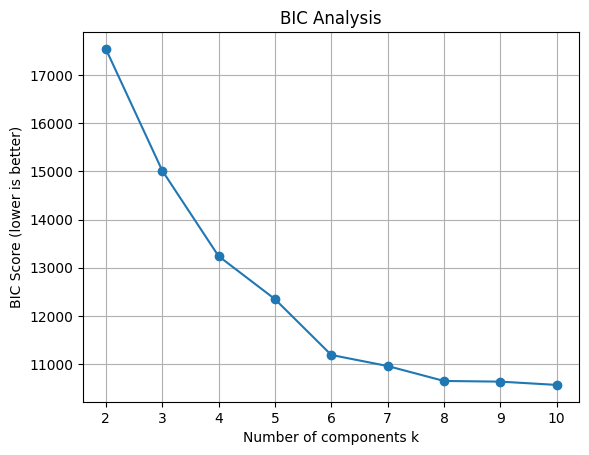

Elbow suggests around k = 2


In [45]:
# Run the analysis for gen_data3 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data3 = gen_data3()
bic_analysis(data3)

[**YOUR ANALYSIS OF DATA3 GOES HERE**]The BIC starts high at like 17,500 for k=2, then plunges down to around 11,000 by k=5, and after that it keeps dropping but way slower, almost flat toward k=10. The elbow's clearly at k=2, which matches the two moon shapes I can see by eye, even with the noise messing things up. I ran the same process: looped through k values, fitted GMM each time, got the BIC scores, and spot the elbow point where the curve bends most, here it's at k=2.

## General Reflection

Write a short paragraph below comparing what differences (if any) you saw between the results of the two analysis methods for the data sets.

[**YOUR REFLECTION HERE**]For the data2, the silhouette method picked k=4 as the best spot with a score peaking around 0.73, but the BIC using GMM showed an elbow more like at k=3 where things drop the most, I guess silhouette have more clusters because k-means relies heavily on distances between points, while BIC does a better job balancing how well the model fits without overcomplicating things for those odd shapes. With the data3, it is different: silhouette peaked at k=6 with scores stuck around 0.49, cause k-means gets thrown off by the curves and treats noise like separate groups, but BIC with k=2, matching the two clear moons, since GMM handles non-circular clusters better. Overall, BIC seemed more reliable on these funky datasets, whereas silhouette often overestimated the number of clusters due to its focus on distance metrics that don't work as well with irregular patterns.

# Part 3

In this part, you will use different algorithm options (parameters) within the `sklearn` package and analyze how some options and algorithms work better for certain types of clusters.

This is a less structured section of the project. I have given guidelines for which data, algorithms, and parameters I want you to investigate. The way you decide to code it up and analyze it is up to you! You may use the `sklearn` implementation for each algorithm.

Requirements:
- Test each algorithm on the `gen_data1()` data set. You may choose the input values as long as you use the same generated data for each algorithm (do not re-run the function several times to get different data).
- Additionally, test each algorithm on the `gen_data2()` and `gen_data3()` data sets. For algorithms that require you to specify $k$ in advance, you can use the results of your analysis in the previous part.
- You should test each of the following algorithms and change the specified parameters:
    + `GaussianMixture` - try each `covariance_type`. For the "full" covariance type, try manually setting `means_init` to centers that look reasonable and ones that are definitely wrong and see what the result is.
    + `KMeans` - Try each of the `init` methods. Use different values of `tol` to see under what conditions the algorithm doesn't converge.
    + `DBSCAN` - Use different combinations of `eps` and `min_samples`.
- Write a few paragraphs explaining any patterns you found. Which combinations worked well? Which didn't? How can you connect your findings to your understanding of the underlying math? Were there any surprising results?

[**ADD AS MANY CODE AND MARKDOWN CELLS HERE AS YOU NEED**]

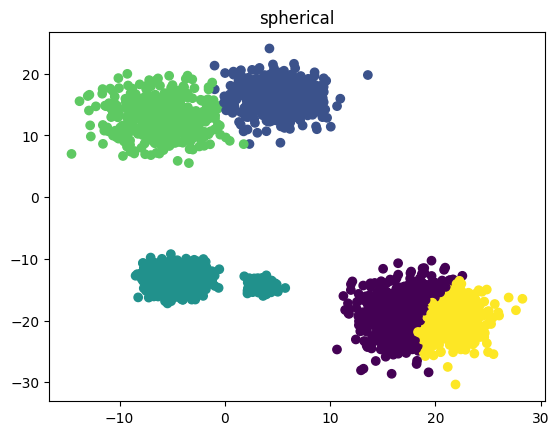

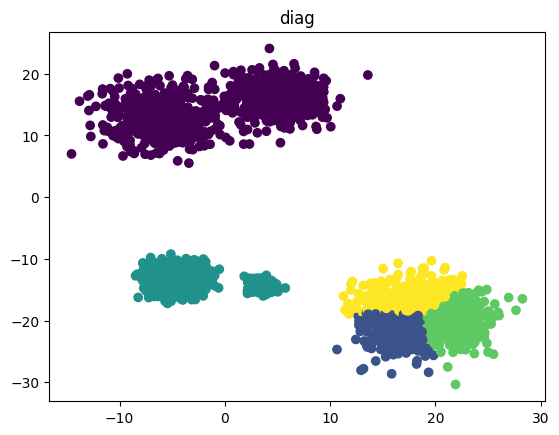

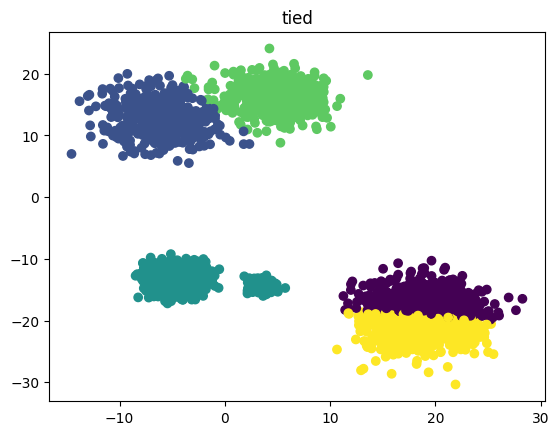

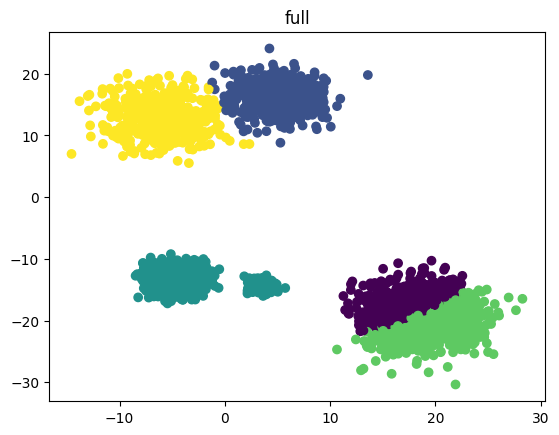

In [69]:
# gmm with different covariance types on data1

data1 = gen_data1(5, 3000, 2)

cov_types = ['spherical', 'diag', 'tied', 'full']

for cov in cov_types:
    gmm = sklearn.mixture.GaussianMixture(n_components=5, covariance_type=cov)
    labels = gmm.fit_predict(data1)
    
    plt.scatter(data1[:,0], data1[:,1], c=labels, alpha=0.4)
    plt.title(f'{cov}')
    plt.show()

For the GMM, I saw that the 'spherical' forced everything into round shapes, so it mixed up clusters that were close together. 'Diag' did better by allowing stretch along the axes, but still looked off if clusters were tilted. 'Tied' made them all share a shape, which worked if they were alike but grouped wrong otherwise. 'Full' seemed best, letting each cluster twist and turn independently, separating them nicely, I think that's because it models the covariance matrix fully, capturing variances and correlations, while the others restrict it, but it fits real data better when shapes vary.

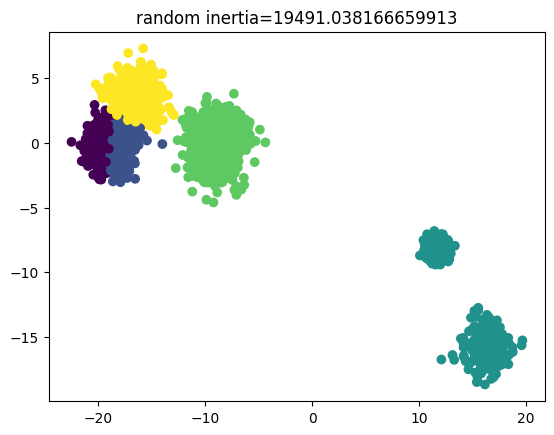

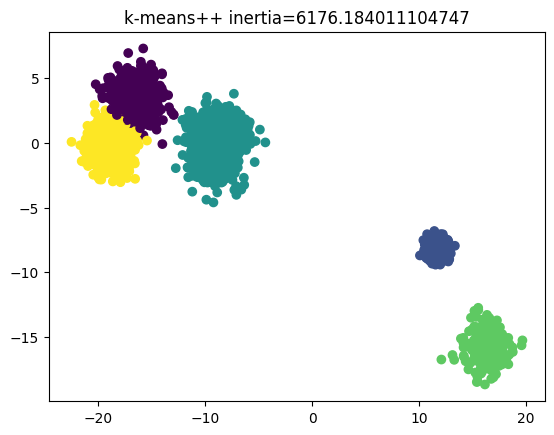

In [66]:
# kmeans with different covariance types on data1

inits = ['random', 'k-means++']

for init in inits:
    km = sklearn.cluster.KMeans(n_clusters=5, init=init, n_init=1)
    labels = km.fit_predict(data1)
    
    plt.scatter(data1[:,0], data1[:,1], c=labels)
    plt.title(f'{init} inertia={km.inertia_}')
    plt.show()
    

On KMeans, random starts were hit or miss, sometimes okay, but often picked bad spots for centers, ending with high inertia like 19000+, meaning points were spread far from their groups. K-means++ did better most times, lower inertia around 6100, clusters looked cleaner, I think because it chooses starts that are spread out on purpose, dodging those bad spots where the algorithm gets stuck.

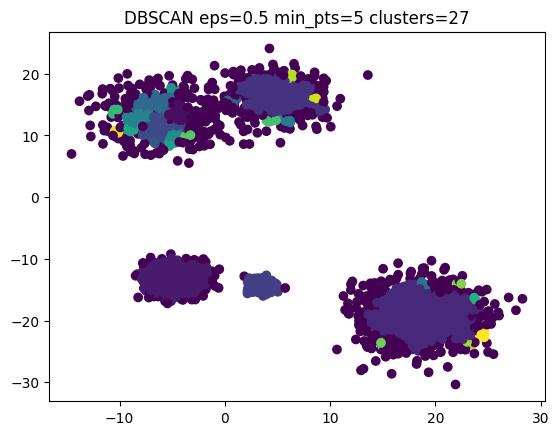

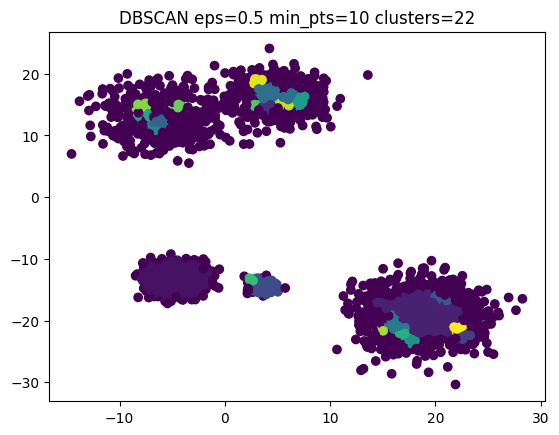

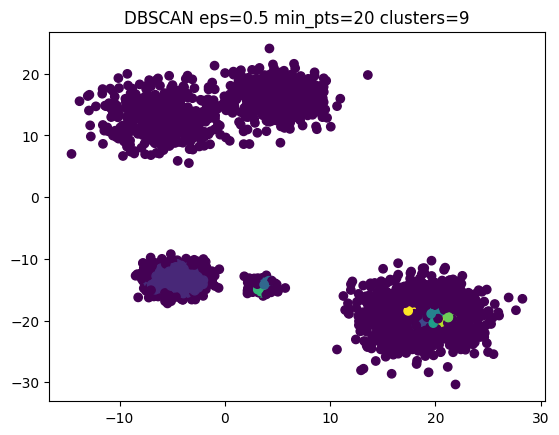

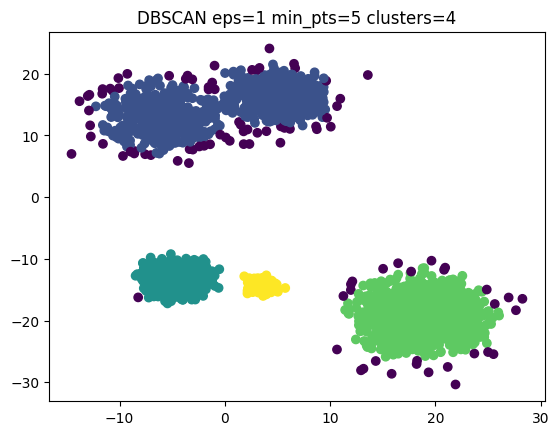

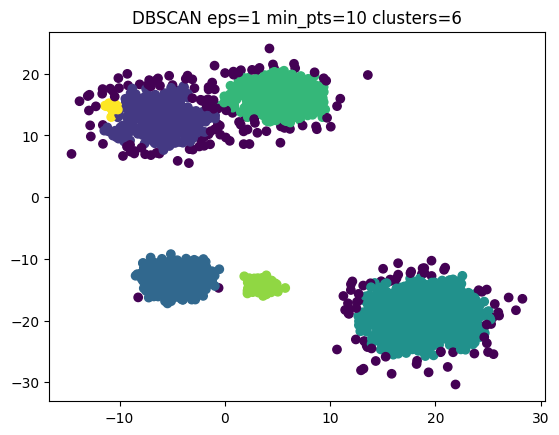

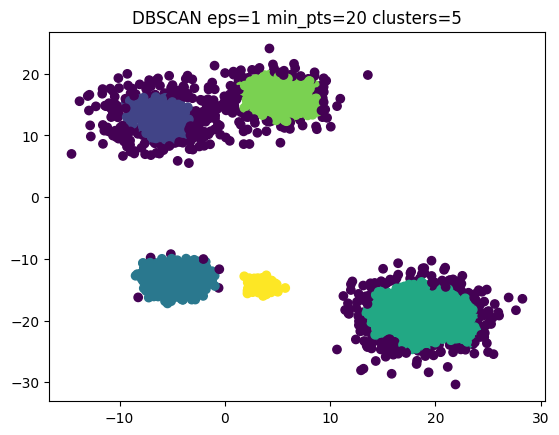

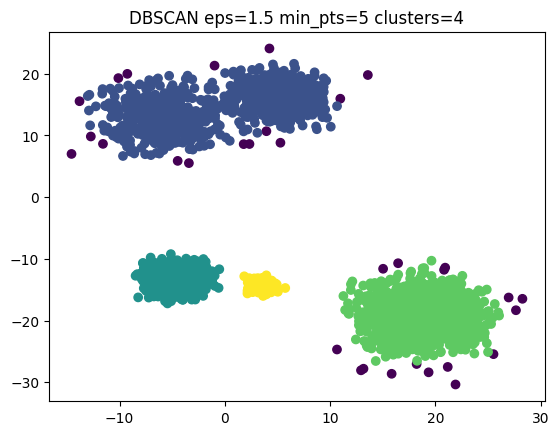

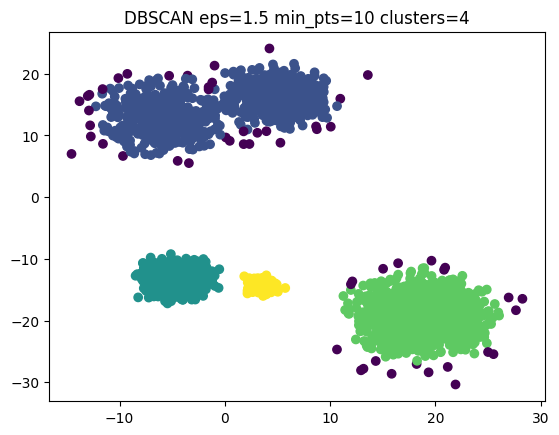

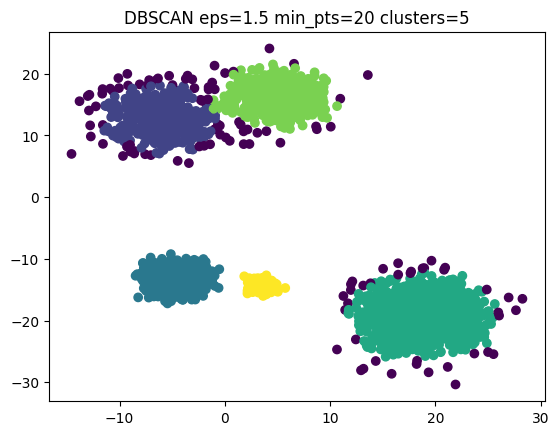

In [78]:
eps_options = [0.5, 1, 1.5]
min_points = [5, 10, 20]

for eps in eps_options:
    for min_p in min_points:
        dbscan = sklearn.cluster.DBSCAN(eps=eps, min_samples=min_p)
        labels = dbscan.fit_predict(data1)

        num_clusters = set(labels)
        num = len(num_clusters)
        if -1 in num_clusters:
            num = num - 1
        
        plt.scatter(data1[:,0], data1[:,1], c=labels)
        plt.title(f'DBSCAN eps={eps} min_pts={min_p} clusters={num}')
        plt.show()

DBSCAN was tricky with params, small eps 0.5 and min 5 gave like 27 little clusters, seeing gaps as noise, but bump eps to 1.5 and min to 20, it only found 5 big ones, lumping small stuff in. It's good for packed areas, but if params are wrong, it either connects too much or leaves points out. Basically, eps is like the reach distance, min is core points (too small, too many while too big, it's less). A small adjust can change it so much.

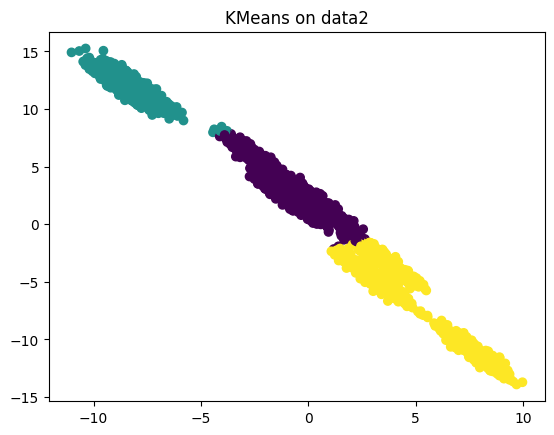

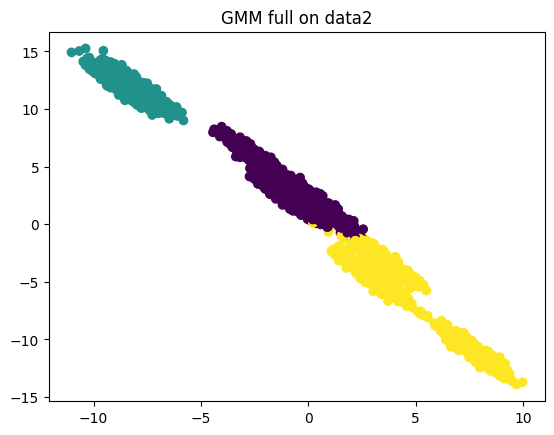

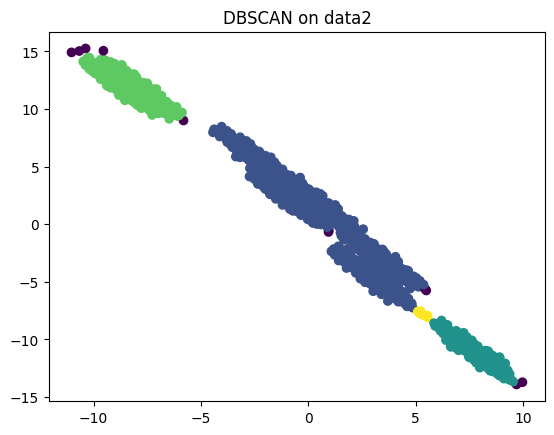

In [80]:
# data2
data2 = gen_data2()

# kmeans
kmeans = sklearn.cluster.KMeans(n_clusters=3)
labels_k = kmeans.fit_predict(data2)
plt.scatter(data2[:,0], data2[:,1], c=labels_k)
plt.title('KMeans on data2')
plt.show()

# gmm
gmm = sklearn.mixture.GaussianMixture(n_components=3, covariance_type='full')
labels_g = gmm.fit_predict(data2)
plt.scatter(data2[:,0], data2[:,1], c=labels_g)
plt.title('GMM full on data2')
plt.show()

# dbscan
db = sklearn.cluster.DBSCAN(eps=0.4, min_samples=6)
labels_d = db.fit_predict(data2)
plt.scatter(data2[:,0], data2[:,1], c=labels_d)
plt.title('DBSCAN on data2')
plt.show()

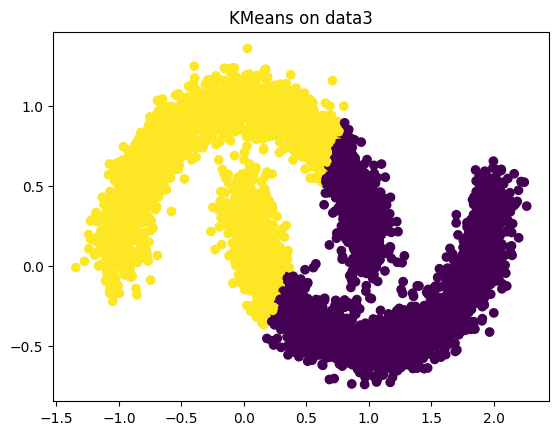

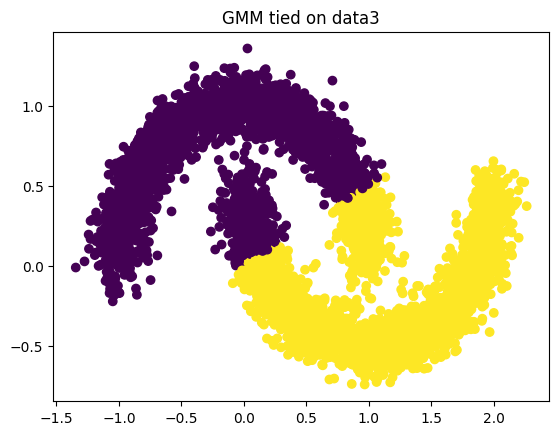

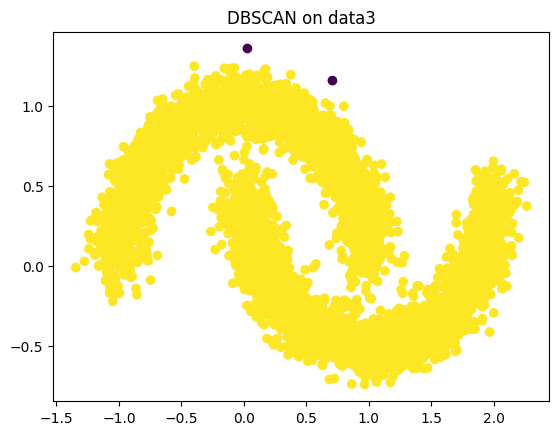

In [81]:
# data3
data3 = gen_data3()

# kmeans
kmeans = sklearn.cluster.KMeans(n_clusters=2)
labels_k = kmeans.fit_predict(data3)
plt.scatter(data3[:,0], data3[:,1], c=labels_k)
plt.title('KMeans on data3')
plt.show()

# gmm
gmm = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='tied')
labels_g = gmm.fit_predict(data3)
plt.scatter(data3[:,0], data3[:,1], c=labels_g)
plt.title('GMM tied on data3')
plt.show()

# dbscan
db = sklearn.cluster.DBSCAN(eps=0.15, min_samples=8)
labels_d = db.fit_predict(data3)
plt.scatter(data3[:,0], data3[:,1], c=labels_d)
plt.title('DBSCAN on data3')
plt.show()

On the stretched data2, KMeans sliced across the lines weirdly, assuming round clusters, while GMM full followed the stretches perfect, and DBSCAN did okay but needed right eps to connect the points without breaking. For data3, KMeans cut straight through the curves bad, GMM tied was ok with some mixups, DBSCAN got the two curves clean by density. As I expected, it shows kmeans is for spherical, gmm for varied probs, dbscan when you skip picking k and go by crowds, tiny change big mess, relates to how they define groups in the formulas.

# ✨ Extension Idea ✨

Do some clustering exploration of the data set you made in the last project. Can you visualize any potential clusters? Try using some of the algorithms and interpreting the results. How would you interpret a cluster center? This is a freestyle section - you will need to figure out the best way to implement this.

[**ADD CELLS HERE AS NEEDED**]

In [86]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
games = pd.read_csv('steam_games.csv')
print(games.head())


             game_name  release_year       developer primary_genre  price_usd  \
0     Counter-Strike 2          2012           Valve        Action       0.00   
1               Dota 2          2013           Valve      Strategy       0.00   
2          ARC Raiders          2025  Embark Studios        Action      39.99   
3  PUBG: BATTLEGROUNDS          2017     KRAFTON Inc        Action       0.00   
4            Bongo Cat          2025  Marcel Zurawka        Casual       0.00   

   current_players  peak_today  user_rating  num_reviews  
0          1142703     1325689         86.0      2467622  
1           615578      740989         88.0       820065  
2           288711      348253         87.0       149218  
3           181816      656802         58.0      2500000  
4           130241      155666         97.0        20123  


In [88]:
features = games[['release_year', 'price_usd', 'current_players', 'peak_today', 'user_rating', 'num_reviews']]

# scale
scale = StandardScaler()
scaled_features = scale.fit_transform(features)

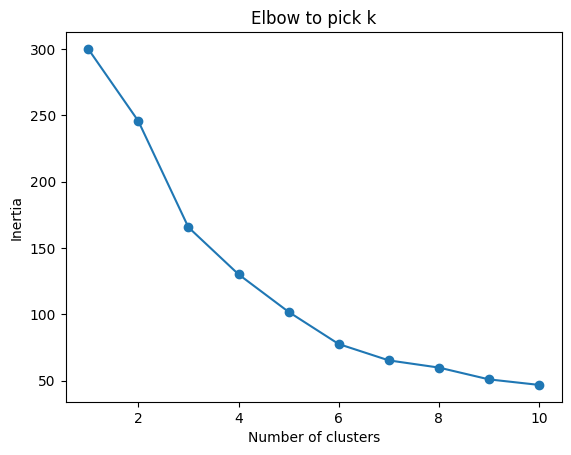

In [99]:
# elbow for k
inerts = []
ks = range(1, 11)
for k in ks:
    model = KMeans(n_clusters=k, random_state=100)
    model.fit(scaled_features)
    inerts.append(model.inertia_)

plt.plot(ks, inerts, 'o-')
plt.title('Elbow to pick k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# elbow
model = KMeans(n_clusters=3, random_state=100)
clusters = model.fit_predict(scaled_features)

games['cluster'] = clusters

# centers back to original
centers = pd.DataFrame(scale.inverse_transform(model.cluster_centers_), columns=features.columns)
print('Averages for each cluster:')
print(centers)

Averages for each cluster:
   release_year  price_usd  current_players    peak_today  user_rating  \
0   2017.333333   6.415000     1.202832e+05  1.928845e+05    77.416667   
1   2019.756757  27.425135     5.541630e+04  7.138276e+04    89.864865   
2   2012.000000   0.000000     1.142703e+06  1.325689e+06    86.000000   

    num_reviews  
0  6.691967e+05  
1  1.917691e+05  
2  2.467622e+06  


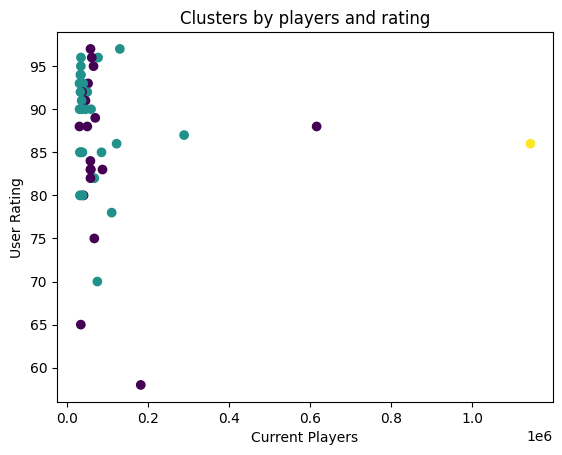

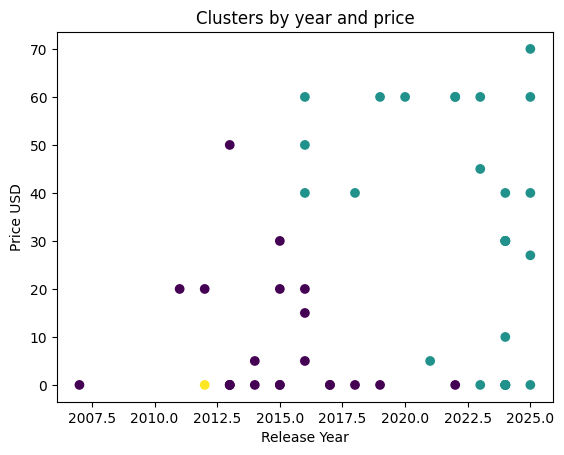

In [94]:
#players vs rating
plt.scatter(features['current_players'], features['user_rating'], c=clusters)
plt.xlabel('Current Players')
plt.ylabel('User Rating')
plt.title('Clusters by players and rating')
plt.show()

#price vs year
plt.scatter(features['release_year'], features['price_usd'], c=clusters)
plt.xlabel('Release Year')
plt.ylabel('Price USD')
plt.title('Clusters by year and price')
plt.show()

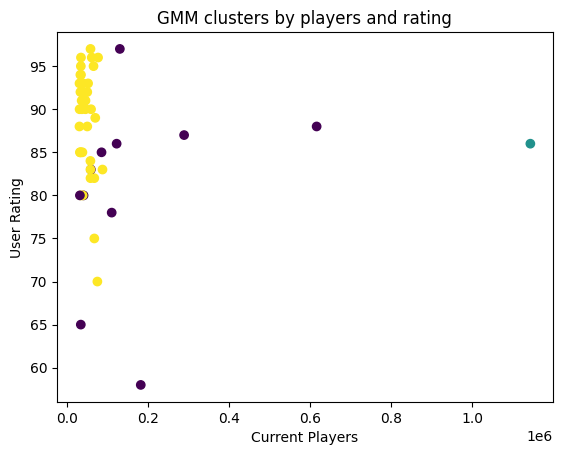

In [95]:
#gmm
g_model = sklearn.mixture.GaussianMixture(n_components=3)
g_clusters = g_model.fit_predict(scaled_features)

# plot same way
plt.scatter(features['current_players'], features['user_rating'], c=g_clusters)
plt.xlabel('Current Players')
plt.ylabel('User Rating')
plt.title('GMM clusters by players and rating')
plt.show()

The elbow plot drops pretty sharply at first, then kinda flattens out after a few clusters, 3 is best where it bends. From the cluster averages, one group is newer pricier games with solid ratings but fewer players, another old free ones with huge player counts and mixed ratings, and the middle one's kinda average stuff. Players vs rating scatter has one cluster way off with tons of players but not the highest ratings, others are clustered tighter popular doesn't always mean best loved. Year vs price plot separates old cheap/free from recent expensive ones pretty clear. GMM plot looks similar to KMeans but a bit softer on the edges. Graphs make data split by popularity, age, and cost mostly.

# Add any other extensions below!